### Human Capital Simulation Model - Variable Descriptions

This model simulates potential human capital and financial asset accumulation over a working life, accounting for various financial events and probabilities.

#### Variables

- **age**: Starting age for the simulation.
- **retirement_age**: Expected retirement age, determining the length of the working life in years.
- **init_salary**: Initial salary at the starting age (in EUR).
- **bonus**: Annual bonus amount added to the gross income (in EUR).
- **salary_growth_mean**: Expected average annual salary growth rate.
- **salary_growth_std**: Standard deviation for salary growth, representing the variability in annual increases.
- **savings_rate**: Percentage of net income saved each year after taxes.
- **investment_return**: Expected annual rate of return on accumulated savings.
- **inflation_rate**: Annual inflation rate, which reduces purchasing power and affects real returns.
- **income_shock_prob**: Probability of an income shock (e.g., job loss or reduction), causing a temporary 20% reduction in net income.
- **tax_rate**: Percentage of gross income deducted for taxes each year.
- **catastrophic_event_prob**: Probability of a catastrophic event (e.g., major unexpected cost) in any given year.
- **catastrophic_event_cost**: Fixed cost incurred if a catastrophic event occurs, deducted from total savings (in EUR).
- **num_simulations**: Number of Monte Carlo simulations to run, improving the robustness of the projections.
  
This model provides insights into expected financial outcomes by running a Monte Carlo simulation that factors in income, savings, investment returns, and possible financial setbacks.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox, Output, VBox, HBox, Button

# Function to run the Monte Carlo simulation with mortgage option
def simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                  savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                                  catastrophic_event_prob, catastrophic_event_cost, salary_cap, include_mortgage,
                                  depreciation_rate, num_simulations=10000):

    years = retirement_age - age
    total_human_capital = np.zeros(num_simulations)
    financial_assets_over_time = []
    real_asset_over_time = []

    for i in range(num_simulations):
        salary = init_salary
        total_savings = 0
        real_asset_value = 0  # Initialize real estate asset value
        financial_path = []
        real_asset_path = []

        for year in range(years):
            # Apply salary growth with randomness and cap
            growth_rate = np.random.normal(salary_growth_mean, salary_growth_std)
            salary *= (1 + growth_rate)
            salary = min(salary, salary_cap)

            gross_income = salary + bonus
            tax_amount = gross_income * tax_rate
            net_income = gross_income - tax_amount

            # Income shock
            if np.random.rand() < income_shock_prob:
                net_income *= 0.8

            # Savings and consumption calculation with mortgage
            if include_mortgage:
                mortgage_payment = net_income * 0.5  # 50% of consumption goes to mortgage payments
                annual_savings = (net_income * savings_rate)  # Regular savings rate applied to net income
                real_asset_value += mortgage_payment  # Add mortgage payment to real asset value
                # Depreciate and appreciate asset value
                real_asset_value = real_asset_value * (1 - depreciation_rate) * (1 + inflation_rate)
            else:
                annual_savings = net_income * savings_rate

            # Update savings with investment returns
            total_savings = (total_savings + annual_savings) * (1 + investment_return - inflation_rate)

            # Catastrophic event
            if np.random.rand() < catastrophic_event_prob:
                total_savings -= catastrophic_event_cost

            total_savings = max(0, total_savings)

            # Track financial assets and real asset over time
            financial_path.append(total_savings)
            real_asset_path.append(real_asset_value if include_mortgage else 0)

        # Store the final wealth including real asset
        final_wealth = total_savings + real_asset_value if include_mortgage else total_savings
        total_human_capital[i] = final_wealth
        financial_assets_over_time.append(financial_path)
        real_asset_over_time.append(real_asset_path)

    return total_human_capital, np.array(financial_assets_over_time).T, np.array(real_asset_over_time).T

# Function to plot results with mortgage option
def plot_mortgage_results(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                          savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                          catastrophic_event_prob, catastrophic_event_cost, salary_cap, include_mortgage,
                          depreciation_rate, num_simulations):

    # Run the simulation
    total_human_capital, financial_assets_over_time, real_asset_over_time = simulate_wealth_with_mortgage(
        age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std, savings_rate,
        investment_return, inflation_rate, income_shock_prob, tax_rate, catastrophic_event_prob,
        catastrophic_event_cost, salary_cap, include_mortgage, depreciation_rate, num_simulations
    )

    # Calculate mean paths for financial and real assets over time
    mean_financial_assets = np.mean(financial_assets_over_time, axis=1)
    mean_real_assets = np.mean(real_asset_over_time, axis=1)

    years = np.arange(age, retirement_age)

    # Output to avoid auto-refreshing
    output.clear_output()
    with output:
        print(f"Average Projected Wealth at Retirement (with{'out' if not include_mortgage else ''} mortgage): €{np.mean(total_human_capital):,.2f}")

        # Plot the distribution of total wealth (human + real asset if mortgage)
        plt.figure(figsize=(10, 6))
        plt.hist(total_human_capital, bins=50, color='skyblue', edgecolor='black')
        plt.title("Distribution of Projected Wealth (Financial + Real Asset)")
        plt.xlabel("Total Projected Wealth (EUR)")
        plt.ylabel("Frequency")
        plt.axvline(np.mean(total_human_capital), color='orange', linestyle='dashed', linewidth=2, label='Mean')
        plt.legend()
        plt.show()

        # Plot area chart for financial and real assets over time
        plt.figure(figsize=(10, 6))
        plt.fill_between(years, mean_financial_assets, color='lightblue', label='Financial Assets')
        plt.fill_between(years, mean_financial_assets + mean_real_assets, color='lightgreen', alpha=0.6, label='Real Asset')
        plt.title("Wealth Accumulation Over Time (Financial + Real Asset)")
        plt.xlabel("Age")
        plt.ylabel("Value (€)")
        plt.legend()
        plt.show()

        # Stacked area chart for financial and real asset accumulation over time
        mean_consumption = mean_financial_assets * (1 - savings_rate)
        mean_savings = mean_financial_assets * savings_rate

        plt.figure(figsize=(10, 6))
        plt.stackplot(years, mean_savings, mean_consumption, mean_real_assets,
                      labels=['Savings', 'Consumption', 'Real Asset'], colors=['#B0E57C', '#ADD8E6', '#FFB6C1'])
        plt.title("Wealth Distribution Over Time (Including Real Asset)")
        plt.xlabel("Age")
        plt.ylabel("Amount (€)")
        plt.legend(loc="upper left")
        plt.show()

# Widgets for parameters
age = IntSlider(value=29, min=20, max=40, step=1, description='Age')
retirement_age = IntSlider(value=65, min=60, max=70, step=1, description='Retirement Age')
init_salary = FloatSlider(value=55000, min=30000, max=100000, step=1000, description='Initial Salary (€)')
bonus = FloatSlider(value=5000, min=0, max=10000, step=500, description='Bonus (€)')
salary_growth_mean = FloatSlider(value=0.04, min=0.01, max=0.1, step=0.005, description='Salary Growth Mean')
salary_growth_std = FloatSlider(value=0.02, min=0, max=0.05, step=0.005, description='Growth Std Dev')
savings_rate = FloatSlider(value=0.2, min=0, max=0.5, step=0.05, description='Savings Rate')
investment_return = FloatSlider(value=0.1, min=0, max=0.2, step=0.01, description='Investment Return')
inflation_rate = FloatSlider(value=0.02, min=0, max=0.05, step=0.005, description='Inflation Rate')
income_shock_prob = FloatSlider(value=0.05, min=0, max=0.2, step=0.01, description='Income Shock Probability')
tax_rate = FloatSlider(value=0.25, min=0, max=0.5, step=0.05, description='Tax Rate')
catastrophic_event_prob = FloatSlider(value=0.02, min=0, max=0.1, step=0.005, description='Catastrophic Event Prob')
catastrophic_event_cost = FloatSlider(value=20000, min=5000, max=50000, step=1000, description='Catastrophic Event Cost (€)')
salary_cap = FloatSlider(value=150000, min=50000, max=500000, step=5000, description='Salary Cap (€)')
num_simulations = IntSlider(value=10000, min=1000, max=100000, step=1000, description='Simulations')
include_mortgage = Checkbox(value=False, description="Include Mortgage")
depreciation_rate = FloatSlider(value=0.01, min=0, max=0.05, step=0.005, description='Depreciation Rate')

# Output widget to display the results
output = Output()

# Button widget
run_button = Button(description="Run Simulation")

# Function to handle button click event
def on_button_click(b):
    plot_mortgage_results(age.value, retirement_age.value, init_salary.value, bonus.value,
                          salary_growth_mean.value, salary_growth_std.value, savings_rate.value,
                          investment_return.value, inflation_rate.value, income_shock_prob.value,
                          tax_rate.value, catastrophic_event_prob.value, catastrophic_event_cost.value,
                          salary_cap.value, include_mortgage.value, depreciation_rate.value, num_simulations.value)

# Bind the button click event to the function
run_button.on_click(on_button_click)

# Display all widgets and the output area
display(VBox([
    HBox([age, retirement_age, init_salary, bonus]),
    HBox([salary_growth_mean, salary_growth_std, savings_rate, investment_return]),
    HBox([inflation_rate, income_shock_prob, tax_rate, catastrophic_event_prob]),
    HBox([catastrophic_event_cost, salary_cap, num_simulations]),
    HBox([include_mortgage, depreciation_rate]),
    run_button,
    output
]))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import t
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox, Output, VBox, HBox, Button

# Function to run the Monte Carlo simulation with mortgage option
def simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                  savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                                  catastrophic_event_prob, catastrophic_event_cost, salary_cap, include_mortgage,
                                  depreciation_rate, num_simulations=10000):

    years = retirement_age - age
    total_human_capital = np.zeros(num_simulations)
    financial_assets_over_time = []
    real_asset_over_time = []

    for i in range(num_simulations):
        salary = init_salary
        total_savings = 0
        real_asset_value = 0  # Initialize real estate asset value
        financial_path = []
        real_asset_path = []

        for year in range(years):
            growth_rate = np.random.normal(salary_growth_mean, salary_growth_std)
            salary *= (1 + growth_rate)
            salary = min(salary, salary_cap)

            gross_income = salary + bonus
            tax_amount = gross_income * tax_rate
            net_income = gross_income - tax_amount

            if np.random.rand() < income_shock_prob:
                net_income *= 0.8

            if include_mortgage:
                mortgage_payment = net_income * 0.5  # 50% of consumption goes to mortgage payments
                annual_savings = net_income * savings_rate
                real_asset_value += mortgage_payment
                real_asset_value = real_asset_value * (1 - depreciation_rate) * (1 + inflation_rate)
            else:
                annual_savings = net_income * savings_rate

            total_savings = (total_savings + annual_savings) * (1 + investment_return - inflation_rate)
            if np.random.rand() < catastrophic_event_prob:
                total_savings -= catastrophic_event_cost
            total_savings = max(0, total_savings)

            financial_path.append(total_savings)
            real_asset_path.append(real_asset_value if include_mortgage else 0)

        final_wealth = total_savings + real_asset_value if include_mortgage else total_savings
        total_human_capital[i] = final_wealth
        financial_assets_over_time.append(financial_path)
        real_asset_over_time.append(real_asset_path)

    return total_human_capital, np.array(financial_assets_over_time).T, np.array(real_asset_over_time).T

# Sensitivity Analysis Function
def sensitivity_analysis(baseline_wealth, age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                         savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                         catastrophic_event_prob, catastrophic_event_cost, salary_cap, include_mortgage,
                         depreciation_rate, num_simulations):

    factors = {
        "Salary Growth Mean": (salary_growth_mean * 1.1, salary_growth_mean * 0.9),
        "Savings Rate": (savings_rate * 1.1, savings_rate * 0.9),
        "Investment Return": (investment_return * 1.1, investment_return * 0.9),
        "Inflation Rate": (inflation_rate * 1.1, inflation_rate * 0.9),
        "Income Shock Probability": (income_shock_prob * 1.1, income_shock_prob * 0.9),
        "Catastrophic Event Probability": (catastrophic_event_prob * 1.1, catastrophic_event_prob * 0.9),
        "Catastrophic Event Cost": (catastrophic_event_cost * 1.1, catastrophic_event_cost * 0.9),
        "Salary Cap": (salary_cap * 1.1, salary_cap * 0.9)
    }

    impacts = {}

    for factor, (increase, decrease) in factors.items():
        if factor == "Salary Growth Mean":
            wealth_increase = np.mean(simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, increase, salary_growth_std,
                                                                    savings_rate, investment_return, inflation_rate, income_shock_prob,
                                                                    tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                                                    salary_cap, include_mortgage, depreciation_rate, num_simulations)[0])
        elif factor == "Savings Rate":
            wealth_increase = np.mean(simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                                                    increase, investment_return, inflation_rate, income_shock_prob,
                                                                    tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                                                    salary_cap, include_mortgage, depreciation_rate, num_simulations)[0])
        elif factor == "Investment Return":
            wealth_increase = np.mean(simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                                                    savings_rate, increase, inflation_rate, income_shock_prob,
                                                                    tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                                                    salary_cap, include_mortgage, depreciation_rate, num_simulations)[0])
        elif factor == "Inflation Rate":
            wealth_increase = np.mean(simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                                                    savings_rate, investment_return, increase, income_shock_prob,
                                                                    tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                                                    salary_cap, include_mortgage, depreciation_rate, num_simulations)[0])
        elif factor == "Income Shock Probability":
            wealth_increase = np.mean(simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                                                    savings_rate, investment_return, inflation_rate, increase,
                                                                    tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                                                    salary_cap, include_mortgage, depreciation_rate, num_simulations)[0])
        elif factor == "Catastrophic Event Probability":
            wealth_increase = np.mean(simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                                                    savings_rate, investment_return, inflation_rate, income_shock_prob,
                                                                    tax_rate, increase, catastrophic_event_cost,
                                                                    salary_cap, include_mortgage, depreciation_rate, num_simulations)[0])
        elif factor == "Catastrophic Event Cost":
            wealth_increase = np.mean(simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                                                    savings_rate, investment_return, inflation_rate, income_shock_prob,
                                                                    tax_rate, catastrophic_event_prob, increase,
                                                                    salary_cap, include_mortgage, depreciation_rate, num_simulations)[0])
        elif factor == "Salary Cap":
            wealth_increase = np.mean(simulate_wealth_with_mortgage(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                                                    savings_rate, investment_return, inflation_rate, income_shock_prob,
                                                                    tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                                                    increase, include_mortgage, depreciation_rate, num_simulations)[0])

        impact_increase = ((wealth_increase - baseline_wealth) / baseline_wealth) * 100
        impacts[factor] = impact_increase

    return impacts

# KPIs and Distribution Analysis
def wealth_distribution_kpis(total_human_capital):
    mean_wealth = np.mean(total_human_capital)
    median_wealth = np.median(total_human_capital)
    std_dev_wealth = np.std(total_human_capital, ddof=1)
    skewness = stats.skew(total_human_capital)
    kurtosis = stats.kurtosis(total_human_capital)
    conf_interval = t.interval(0.95, len(total_human_capital) - 1, loc=mean_wealth, scale=std_dev_wealth / np.sqrt(len(total_human_capital)))

    print(f"Mean Wealth: €{mean_wealth:,.2f}")
    print(f"Median Wealth: €{median_wealth:,.2f}")
    print(f"Standard Deviation: €{std_dev_wealth:,.2f}")
    print(f"95% Confidence Interval: (€{conf_interval[0]:,.2f}, €{conf_interval[1]:,.2f})")
    print(f"Skewness: {skewness:.2f}")
    print(f"Kurtosis: {kurtosis:.2f}")

    plt.figure(figsize=(10, 6))
    plt.hist(total_human_capital, bins=50, color='tan', edgecolor='black')
    plt.title("Distribution of Projected Wealth")
    plt.xlabel("Total Projected Wealth (EUR)")
    plt.ylabel("Frequency")
    plt.axvline(mean_wealth, color='black', linestyle='dashed', linewidth=2, label='Mean')
    plt.axvline(median_wealth, color='peru', linestyle='dashed', linewidth=2, label='Median')
    plt.legend()
    plt.show()

# Plot Results Wrapper
def plot_mortgage_results_with_kpi_and_sensitivity(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                                   savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                                                   catastrophic_event_prob, catastrophic_event_cost, salary_cap, include_mortgage,
                                                   depreciation_rate, num_simulations):

    total_human_capital, financial_assets_over_time, real_asset_over_time = simulate_wealth_with_mortgage(
        age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std, savings_rate,
        investment_return, inflation_rate, income_shock_prob, tax_rate, catastrophic_event_prob,
        catastrophic_event_cost, salary_cap, include_mortgage, depreciation_rate, num_simulations
    )

    wealth_distribution_kpis(total_human_capital)
    baseline_wealth = np.mean(total_human_capital)

    impacts = sensitivity_analysis(baseline_wealth, age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                   savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                                   catastrophic_event_prob, catastrophic_event_cost, salary_cap, include_mortgage,
                                   depreciation_rate, num_simulations)

    plt.figure(figsize=(10, 6))
    plt.bar(impacts.keys(), impacts.values(), color='tan')
    plt.xlabel("Factors")
    plt.ylabel("Impact on Wealth Creation (%)")
    plt.title("Sensitivity Analysis: Impact of Factors on Wealth Creation")
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Button Action
def on_button_click(b):
    plot_mortgage_results_with_kpi_and_sensitivity(
        age.value, retirement_age.value, init_salary.value, bonus.value,
        salary_growth_mean.value, salary_growth_std.value, savings_rate.value,
        investment_return.value, inflation_rate.value, income_shock_prob.value,
        tax_rate.value, catastrophic_event_prob.value, catastrophic_event_cost.value,
        salary_cap.value, include_mortgage.value, depreciation_rate.value, num_simulations.value)

# Widget Setup remains the same
# Widgets for parameters (Setup remains the same as previously defined)
age = IntSlider(value=29, min=20, max=40, step=1, description='Age')
retirement_age = IntSlider(value=65, min=60, max=70, step=1, description='Retirement Age')
init_salary = FloatSlider(value=55000, min=30000, max=100000, step=1000, description='Initial Salary (€)')
bonus = FloatSlider(value=5000, min=0, max=10000, step=500, description='Bonus (€)')
salary_growth_mean = FloatSlider(value=0.04, min=0.01, max=0.1, step=0.005, description='Salary Growth Mean')
salary_growth_std = FloatSlider(value=0.02, min=0, max=0.05, step=0.005, description='Growth Std Dev')
savings_rate = FloatSlider(value=0.2, min=0, max=0.5, step=0.05, description='Savings Rate')
investment_return = FloatSlider(value=0.1, min=0, max=0.2, step=0.01, description='Investment Return')
inflation_rate = FloatSlider(value=0.02, min=0, max=0.05, step=0.005, description='Inflation Rate')
income_shock_prob = FloatSlider(value=0.05, min=0, max=0.2, step=0.01, description='Income Shock Probability')
tax_rate = FloatSlider(value=0.25, min=0, max=0.5, step=0.05, description='Tax Rate')
catastrophic_event_prob = FloatSlider(value=0.02, min=0, max=0.1, step=0.005, description='Catastrophic Event Prob')
catastrophic_event_cost = FloatSlider(value=20000, min=5000, max=50000, step=1000, description='Catastrophic Event Cost (€)')
salary_cap = FloatSlider(value=150000, min=50000, max=500000, step=5000, description='Salary Cap (€)')
num_simulations = IntSlider(value=10000, min=1000, max=100000, step=1000, description='Simulations')
include_mortgage = Checkbox(value=False, description="Include Mortgage")
depreciation_rate = FloatSlider(value=0.01, min=0, max=0.05, step=0.005, description='Depreciation Rate')

# Output widget to display the results
output = Output()

# Button widget
run_button = Button(description="Run Simulation")

# Function to handle button click event
def on_button_click(b):
    with output:
        output.clear_output()
        plot_mortgage_results_with_kpi_and_sensitivity(
            age.value, retirement_age.value, init_salary.value, bonus.value,
            salary_growth_mean.value, salary_growth_std.value, savings_rate.value,
            investment_return.value, inflation_rate.value, income_shock_prob.value,
            tax_rate.value, catastrophic_event_prob.value, catastrophic_event_cost.value,
            salary_cap.value, include_mortgage.value, depreciation_rate.value, num_simulations.value)

# Bind the button click event to the function
run_button.on_click(on_button_click)

# Display all widgets and the output area
display(VBox([
    HBox([age, retirement_age, init_salary, bonus]),
    HBox([salary_growth_mean, salary_growth_std, savings_rate, investment_return]),
    HBox([inflation_rate, income_shock_prob, tax_rate, catastrophic_event_prob]),
    HBox([catastrophic_event_cost, salary_cap, num_simulations]),
    HBox([include_mortgage, depreciation_rate]),
    run_button,
    output
]))


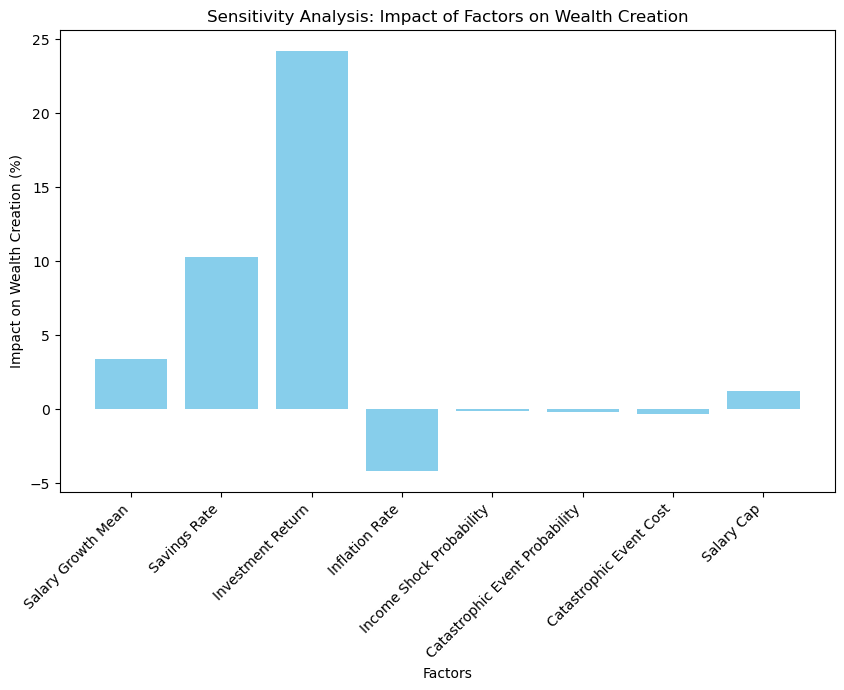

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Function to run the Monte Carlo simulation (simplified for sensitivity analysis)
def simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                    savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                    catastrophic_event_prob, catastrophic_event_cost, salary_cap, num_simulations=10000):

    years = retirement_age - age
    total_human_capital = np.zeros(num_simulations)

    for i in range(num_simulations):
        salary = init_salary
        total_savings = 0

        for year in range(years):
            # Apply salary growth with randomness and cap
            growth_rate = np.random.normal(salary_growth_mean, salary_growth_std)
            salary *= (1 + growth_rate)
            salary = min(salary, salary_cap)

            gross_income = salary + bonus
            tax_amount = gross_income * tax_rate
            net_income = gross_income - tax_amount

            # Income shock
            if np.random.rand() < income_shock_prob:
                net_income *= 0.8

            # Savings and consumption
            annual_savings = net_income * savings_rate
            total_savings = (total_savings + annual_savings) * (1 + investment_return - inflation_rate)

            # Catastrophic event
            if np.random.rand() < catastrophic_event_prob:
                total_savings -= catastrophic_event_cost

            total_savings = max(0, total_savings)

        total_human_capital[i] = total_savings

    return np.mean(total_human_capital)  # Return average human capital for baseline comparison

# Function to calculate sensitivity for each factor
def sensitivity_analysis(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                         savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                         catastrophic_event_prob, catastrophic_event_cost, salary_cap, num_simulations=10000):

    # Run baseline simulation
    baseline_wealth = simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean,
                                      salary_growth_std, savings_rate, investment_return, inflation_rate,
                                      income_shock_prob, tax_rate, catastrophic_event_prob,
                                      catastrophic_event_cost, salary_cap, num_simulations)

    # Factors to analyze and their ranges for sensitivity testing
    factors = {
        "Salary Growth Mean": (salary_growth_mean * 1.1, salary_growth_mean * 0.9),
        "Savings Rate": (savings_rate * 1.1, savings_rate * 0.9),
        "Investment Return": (investment_return * 1.1, investment_return * 0.9),
        "Inflation Rate": (inflation_rate * 1.1, inflation_rate * 0.9),
        "Income Shock Probability": (income_shock_prob * 1.1, income_shock_prob * 0.9),
        "Catastrophic Event Probability": (catastrophic_event_prob * 1.1, catastrophic_event_prob * 0.9),
        "Catastrophic Event Cost": (catastrophic_event_cost * 1.1, catastrophic_event_cost * 0.9),
        "Salary Cap": (salary_cap * 1.1, salary_cap * 0.9)
    }

    # Dictionary to store the impact of each factor
    impacts = {}

    # Run simulations for each factor with adjustments
    for factor, (increase, decrease) in factors.items():
        # Increase the factor
        if factor == "Salary Growth Mean":
            wealth_increase = simulate_wealth(age, retirement_age, init_salary, bonus, increase, salary_growth_std,
                                              savings_rate, investment_return, inflation_rate, income_shock_prob,
                                              tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                              salary_cap, num_simulations)
        elif factor == "Savings Rate":
            wealth_increase = simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                              increase, investment_return, inflation_rate, income_shock_prob,
                                              tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                              salary_cap, num_simulations)
        elif factor == "Investment Return":
            wealth_increase = simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                              savings_rate, increase, inflation_rate, income_shock_prob,
                                              tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                              salary_cap, num_simulations)
        elif factor == "Inflation Rate":
            wealth_increase = simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                              savings_rate, investment_return, increase, income_shock_prob,
                                              tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                              salary_cap, num_simulations)
        elif factor == "Income Shock Probability":
            wealth_increase = simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                              savings_rate, investment_return, inflation_rate, increase,
                                              tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                              salary_cap, num_simulations)
        elif factor == "Catastrophic Event Probability":
            wealth_increase = simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                              savings_rate, investment_return, inflation_rate, income_shock_prob,
                                              tax_rate, increase, catastrophic_event_cost,
                                              salary_cap, num_simulations)
        elif factor == "Catastrophic Event Cost":
            wealth_increase = simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                              savings_rate, investment_return, inflation_rate, income_shock_prob,
                                              tax_rate, catastrophic_event_prob, increase,
                                              salary_cap, num_simulations)
        elif factor == "Salary Cap":
            wealth_increase = simulate_wealth(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                              savings_rate, investment_return, inflation_rate, income_shock_prob,
                                              tax_rate, catastrophic_event_prob, catastrophic_event_cost,
                                              increase, num_simulations)

        # Calculate impact as percentage difference from baseline
        impact_increase = ((wealth_increase - baseline_wealth) / baseline_wealth) * 100

        # Store results
        impacts[factor] = impact_increase

    return impacts

# Running sensitivity analysis and plotting results
def plot_sensitivity_results():
    age, retirement_age = 29, 65
    init_salary, bonus = 55000, 5000
    salary_growth_mean, salary_growth_std = 0.04, 0.02
    savings_rate, investment_return, inflation_rate = 0.2, 0.1, 0.02
    income_shock_prob, tax_rate = 0.05, 0.25
    catastrophic_event_prob, catastrophic_event_cost = 0.02, 20000
    salary_cap, num_simulations = 150000, 10000

    impacts = sensitivity_analysis(age, retirement_age, init_salary, bonus, salary_growth_mean, salary_growth_std,
                                   savings_rate, investment_return, inflation_rate, income_shock_prob, tax_rate,
                                   catastrophic_event_prob, catastrophic_event_cost, salary_cap, num_simulations)

    # Plotting impacts
    plt.figure(figsize=(10, 6))
    plt.bar(impacts.keys(), impacts.values(), color='skyblue')
    plt.xlabel("Factors")
    plt.ylabel("Impact on Wealth Creation (%)")
    plt.title("Sensitivity Analysis: Impact of Factors on Wealth Creation")
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Run the plot function
plot_sensitivity_results()